# ROS02 - Map a Scene Autonomously  (LeKiwi - ROS2 - Demo 0-v2)

### Lab Description

Same goal as ROS01 - produce **your** `scene_map` - but the robot **drives itself**. It runs RTAB-Map + Nav2 live while a **frontier explorer** repeatedly sends it to the boundary between known-free and unknown space until your scene is covered, then returns home; the recording is rebuilt offline by the same `build_map.sh` from ROS01. Below we define and run the explorer's core - **frontier detection and selection** - on the map you build.

#### Recommended Hardware
**LeKiwi** omni-directional base (3x Feetech STS3215 wheels on `/dev/ttyACM0`) + **ZED 2i** stereo camera (USB UVC), driven from an **AMD Ryzen AI** machine (Radeon **gfx1152**, RDNA3.5) - AMD-only, no NVIDIA/CUDA.

#### Software Environment
OS: Ubuntu 24.04 - ROCm 7.13 - PyTorch 2.11 (gfx1152 wheel) - **ROS2 Jazzy** + Nav2 + RTAB-Map - conda env `lerobot-new`. This repo ships **only the LeKiwi ROS2 code** in `lekiwi_ros2/` (repo-relative, so it runs from a clone); it does **not** ship any pre-built map or example run - you produce those yourself on the robot. The `numpy`, `opencv-python`, `pyyaml`, `matplotlib` in `lerobot-new` are enough for the analysis cells. One-time robot setup (the `lerobot-new` env, `bash lekiwi_ros2/utils/setup_raft.sh`, `bash lekiwi_ros2/utils/get_calibration.sh <ZED serial>`) is in `lekiwi_ros2/README.md`.

## Goals
- Understand frontier exploration: the free/unknown boundary the robot drives to
- Define and run `find_frontiers` (faithful to auto_explore.py) on YOUR map and visualize it
- Score frontiers with the explore_lite cost and pick the next goal
- Know why the live map is throwaway and the final map is rebuilt offline (ROS01's pipeline)

> **How this notebook works.** Following the MT06 pattern, each key step is a runnable code cell that **defines the function** doing the work and then runs it. The scene-specific cells read **your own** data - the map *you* build (`utils/scene_map.*`), *your* recorded session (`demo0/rec/...`), *your* `odom.txt` - so **every student's result is different**. Before you have produced that data those cells print a short 'run the robot step first' hint (no canned example is shown). The steps that need the physical robot (camera, motors, ROS2) are `bash` commands you run on the LeKiwi; the full implementations live in `lekiwi_ros2/`.

In [1]:
import os, math, glob, configparser
import numpy as np, cv2, yaml
import matplotlib.pyplot as plt

# This repo ships only the LeKiwi ROS2 code (no pre-built map). You produce the map + data.
ROS2  = os.path.abspath("lekiwi_ros2")
UTILS = f"{ROS2}/utils"
print("repo ROS2 folder:", ROS2)

FREE, OCC, UNKNOWN = 254, 0, 205        # ROS map_server PGM pixel values (white / black / grey)
BLOCK_RGB = {"red": "#e53935", "green": "#43a047", "blue": "#1e88e5", "purple": "#8e24aa"}

def latest_session():
    """Newest recording YOU produced (demo0 manual or demo0-v2 auto). None until you record."""
    recs = sorted(glob.glob(f"{ROS2}/demo0/rec/map*") + glob.glob(f"{ROS2}/demo0-v2/rec/map*"))
    return recs[-1] if recs else None

def have_map(name="scene_map"):
    return os.path.exists(f"{UTILS}/{name}.pgm") and os.path.exists(f"{UTILS}/{name}.yaml")

def load_map(name="scene_map"):
    """Load the occupancy grid YOU built (build_map.sh writes it into utils/). Returns
    (grid, res, ox, oy) with grid[gy, gx], gy increasing upward (the ROS map frame)."""
    m = yaml.safe_load(open(f"{UTILS}/{name}.yaml"))
    res, (ox, oy, _) = m["resolution"], m["origin"]
    with open(f"{UTILS}/{m['image']}", "rb") as f:
        assert f.readline().split()[0] == b"P5"
        t = []
        while len(t) < 3:
            t += f.readline().split(b"#")[0].split()
        W, H = int(t[0]), int(t[1])
        raw = np.frombuffer(f.read(W * H), np.uint8).reshape(H, W)
    return np.ascontiguousarray(np.flipud(raw)), res, ox, oy

def new_map_ax(grid, res, ox, oy, title="", figsize=(6, 5)):
    """Show a grid in metric map-frame coordinates and return the Axes for metric overlays."""
    H, W = grid.shape
    ax = plt.subplots(figsize=figsize)[1]
    ax.imshow(grid, cmap="gray", vmin=0, vmax=255, origin="lower",
              extent=[ox, ox + W * res, oy, oy + H * res])
    ax.set_title(title); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_aspect("equal")
    return ax

def load_waypoints():
    """The colour-block positions YOUR build_map.sh saved: {colour: (x, y)} in the map frame."""
    d = {}
    for ln in open(f"{UTILS}/block_waypoints.txt"):
        c, x, y = ln.split(); d[c] = (float(x), float(y))
    return d

def show_my_map():
    """Show the map YOU built, with your block waypoints. Hints if you have not built one yet."""
    if not have_map():
        print("No map yet. Build YOUR map first (run ROS01 or ROS02 on the robot), then re-run.")
        return
    grid, res, ox, oy = load_map()
    ax = new_map_ax(grid, res, ox, oy, "YOUR scene_map")
    if os.path.exists(f"{UTILS}/block_waypoints.txt"):
        for c, (x, y) in load_waypoints().items():
            ax.scatter(x, y, c=BLOCK_RGB.get(c, "orange"), s=90, ec="k", zorder=5, label=c)
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

repo ROS2 folder: /home/aup/aup-teaching-labs/projects/Physical-AI/Real-Deployment/ROS2-Deployment/lekiwi_ros2


## Run it on the robot (one command)

Put the robot at your intended map **origin** first. `demo0_autoexplore.sh` brings up the base driver, ZED depth, RTAB-Map (live mapping), Nav2 (explore config) and the explorer, then chains the offline build. `Ctrl-C` stops + cleans up + halts the motors.

```bash
bash lekiwi_ros2/demo0-v2/demo0_autoexplore.sh              # explore + auto build
bash lekiwi_ros2/demo0-v2/demo0_autoexplore.sh --no-build   # explore/record only
bash lekiwi_ros2/demo0-v2/demo0_autoexplore.sh --no-rviz    # headless
```

## What is a frontier?

A **frontier** is a FREE cell that touches UNKNOWN space and is not hugging an obstacle - literally the edge of the known map. Driving to a frontier and looking around is what grows the map. `find_frontiers` below is faithful to `demo0-v2/auto_explore.py`: it denoises isolated obstacle specks, keeps frontier cells a robot-radius from obstacles, and clusters them, returning one goal `(x, y, size)` per cluster. The run cell uses **your** `utils/scene_map` - so build a map (ROS01 or ROS02) first, then it shows the frontiers of **your** scene:

0 frontier clusters on YOUR map


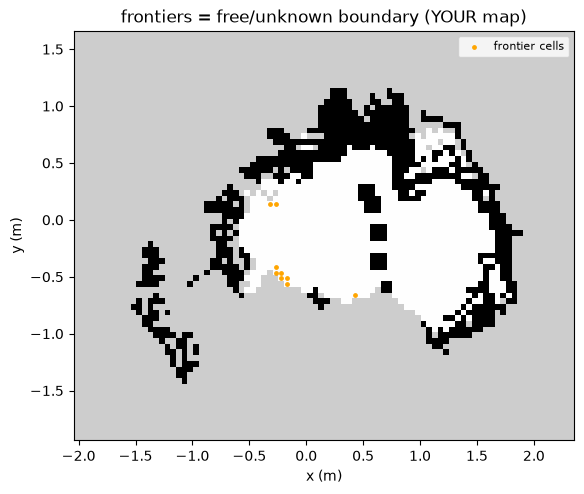

In [2]:
def find_frontiers(grid, res, ox, oy, min_cells=8, robot_r_cells=4, noise_min=4):
    """Frontier clusters [{x, y, size}] (metres) = free cells adjacent to unknown, away
    from obstacles. Faithful to auto_explore.py, on the built PGM (254 free/205 unknown/0 occ)."""
    free    = (grid == FREE).astype(np.uint8)
    unknown = (grid == UNKNOWN).astype(np.uint8)
    occ     = (grid == OCC).astype(np.uint8)
    if noise_min > 1:   # drop isolated occupied specks (VGA-stereo depth noise)
        n, lab, st, _ = cv2.connectedComponentsWithStats(occ, 8)
        keep = [i for i in range(1, n) if st[i, cv2.CC_STAT_AREA] >= noise_min]
        occ = np.isin(lab, keep).astype(np.uint8)
    k3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    unknown_adj = cv2.dilate(unknown, k3)
    occ_dil = cv2.dilate(occ, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*robot_r_cells+1,)*2))
    frontier = (free & unknown_adj & (occ_dil == 0)).astype(np.uint8)
    frontier = cv2.morphologyEx(frontier, cv2.MORPH_CLOSE, k3)
    n, lab, st, cent = cv2.connectedComponentsWithStats(frontier, 8)
    clusters = []
    for i in range(1, n):
        size = int(st[i, cv2.CC_STAT_AREA])
        if size < min_cells:
            continue
        ys, xs = np.where(lab == i)                       # cell nearest the centroid
        j = int(np.argmin((xs - cent[i][0])**2 + (ys - cent[i][1])**2))
        clusters.append({"x": ox + (xs[j]+0.5)*res, "y": oy + (ys[j]+0.5)*res, "size": size})
    return frontier, clusters

grid = res = ox = oy = None; clusters = []
if have_map():
    grid, res, ox, oy = load_map()
    frontier, clusters = find_frontiers(grid, res, ox, oy)
    print(f"{len(clusters)} frontier clusters on YOUR map")
    ax = new_map_ax(grid, res, ox, oy, "frontiers = free/unknown boundary (YOUR map)")
    ys, xs = np.where(frontier)
    ax.scatter(ox + (xs+0.5)*res, oy + (ys+0.5)*res, s=6, c="orange", label="frontier cells")
    for cl in clusters:
        ax.scatter(cl["x"], cl["y"], marker="*", s=220, c="red", ec="k", zorder=6)
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()
else:
    print("No map yet. Build YOUR map (ROS01 or ROS02) first, then re-run to see its frontiers.")

### Choosing the next frontier

With several frontiers to choose from, `explore_lite`'s cost prefers **near** frontiers and **large** openings. Lowest cost wins; the robot drives there, blacklists it, and repeats until none remain - then returns home.

In [3]:
def pick_best_frontier(clusters, robot_xy, res, potential_scale=1.0, gain_scale=0.06):
    """explore_lite cost = potential_scale * distance - gain_scale * size * res.
    Prefer NEAR (small distance) and LARGE (big size) frontiers; lowest cost wins."""
    rx, ry = robot_xy
    def cost(c):
        return potential_scale * math.hypot(c["x"]-rx, c["y"]-ry) - gain_scale * c["size"] * res
    return min(clusters, key=cost) if clusters else None

if clusters:
    robot_xy = (0.0, 0.0)   # e.g. the robot at the map origin
    best = pick_best_frontier(clusters, robot_xy, res)
    print(f"next goal frontier: ({best['x']:+.2f}, {best['y']:+.2f})  size={best['size']} cells")
    ax = new_map_ax(grid, res, ox, oy, "chosen next frontier (star)")
    ax.scatter(*robot_xy, marker="s", s=90, c="deepskyblue", ec="k", zorder=6, label="robot")
    ax.scatter(best["x"], best["y"], marker="*", s=260, c="red", ec="k", zorder=6, label="goal")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()
else:
    print("No frontiers to score yet - build your map and run the previous cell first.")

No frontiers to score yet - build your map and run the previous cell first.


### Why the live map is thrown away

The online map only answers *where do I drive next?* Driving slowly makes the recorded stereo sharper, so after exploration the session is rebuilt with the **offline** `build_map.sh` at `iters=32` - exactly the ROS01 pipeline. That is why ROS01 (manual) and ROS02 (autonomous) produce the same kind of map; either way it is **your** scene, and every student's is different.

## Your result - the map you built

After exploration finishes, the recording is rebuilt offline and `build_map.sh` writes **your** `utils/scene_map.*` + `utils/block_waypoints.txt` (the coloured blocks marked as obstacles) - exactly like ROS01. `show_my_map()` reads those, so once your run completes this shows the map you built with your colour blocks (before that it tells you to build one):

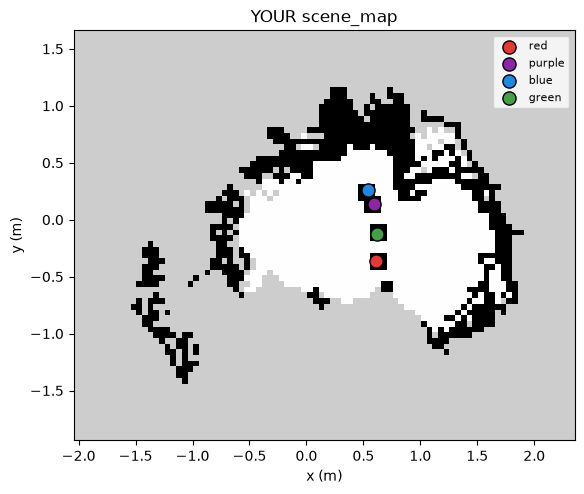

In [4]:
show_my_map()

## Conclusions

You defined and ran the explorer's core: `find_frontiers` (free/unknown boundaries) and `pick_best_frontier` (the explore_lite cost), on **your** map. On the robot, `explore_lite_py.py` loops these against the live `/map` + Nav2 until your scene is covered, records throughout, and rebuilds offline into your `scene_map`. Next: **ROS03** drives to a clicked goal, **ROS04** to a coloured block.

## Acknowledgements

Built on the open-source **LeKiwi** base (Hugging Face **LeRobot**), **RAFT-Stereo** (Princeton), **RTAB-Map**, and **Nav2** on **ROS2 Jazzy**, all running on AMD ROCm (gfx1152) with no NVIDIA/CUDA.

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT